In [ ]:
pip install hmmlearn

In [ ]:
pip install pymongo pandas

In [ ]:
pip install pymongo certifi

In [ ]:
pip install catboost

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
import certifi
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from hmmlearn.vhmm import VariationalGaussianHMM
from catboost import CatBoostClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, precision_score, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler, FunctionTransformer, PolynomialFeatures
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Query the data

In [6]:
def query_mongodb(uri="blured", collection_name="vix_data", db_name="DB_VIX", filtro=None):
    client = MongoClient(uri, tls=True, tlsCAFile=certifi.where())

    db = client[db_name]
    collection = db[collection_name]

    filtro = filtro or {}

    # bring data
    docs = list(collection.find(filtro))

    if not docs:
        return pd.DataFrame()

    df = pd.DataFrame(docs)

    # transform _id to datetime
    if "_id" in df.columns:
        df["_id"] = pd.to_datetime(df["_id"])
        df.set_index("_id", inplace=True)

    return df

In [7]:
data =query_mongodb()
data.tail()

,DXY_overnight,Drawdown,GOLD_overnight,IV_RV_Ratio,Intraday_VIX_Move,Momentum_1M,Momentum_3M,Momentum_6M,OIL_overnight,Open_DXY,...,VIX_Percentile,VIX_RV_Spread,VIX_STD_10,VIX_STD_5,VIX_Trend,VIX_Vol_10d,VIX_Vol_21d,VIX_Vol_5d,VIX_Zscore,VIX_Zscore_Sq
_id,,,,,,,,,,,,,,,,,,,,,
2026-04-13,0.001780,-0.023172,-0.007564,100.509313,0,0.021621,-0.021088,0.028333,0.038379,99.045998,...,0.686508,19.038674,3.336160,2.910115,1.776255,0.079834,0.087251,0.095730,-1.843122,3.397098
2026-04-14,-0.006835,-0.013235,0.013882,99.610632,0,0.038306,-0.005827,0.033348,-0.039314,98.373001,...,0.682540,18.928053,2.627826,2.818434,1.440242,0.080224,0.087241,0.093625,-1.670306,2.789922
2026-04-15,-0.003050,-0.001608,0.015408,95.165532,0,0.040004,0.003299,0.034483,-0.060925,98.070000,...,0.625000,18.167074,2.765928,0.984261,1.094890,0.065485,0.082919,0.072473,-1.707467,2.915443
2026-04-16,-0.000591,0.000000,-0.006194,93.632417,1,0.045690,0.011951,0.042700,-0.005977,98.012001,...,0.615079,17.975943,2.835051,0.575873,0.776298,0.065760,0.082412,0.028482,-1.550317,2.403482
2026-04-17,0.001826,0.000000,0.000187,96.791305,2,0.062883,0.014592,0.051031,-0.019132,98.189003,...,0.595238,17.754653,2.860156,0.578558,0.479794,0.065927,0.077007,0.013409,-1.439769,2.072935


In [8]:
data["Intraday_VIX_Move"]. value_counts()

,count
Intraday_VIX_Move,
1,1708
2,1628
0,1627


## Walk-forward expanding window

In [ ]:
# 1. CLEAN AND SCALE FUNCTION
def clean_features(X):
    """
    Handle missing values and infinite values.
    """
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.ffill().fillna(0)
    return X.astype(np.float64)


# 1.1 PCA PIPELINE
def build_pipeline_pca(n_components=14):
    """
    PCA preprocessing pipeline with scaling and cleaning.
    """
    return Pipeline([
        ("clean", FunctionTransformer(clean_features)),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components))
    ])

def walk_forward_rolling(data, train_size=500, years=13, test_size=500):

    """
    Rolling window forecasting with:
    - First train = 13 years
    - Fixed rolling window = 500
    - Train + Val split (1-step ahead)
    - Final hold-out test set
    """

    X = data.drop(columns=["Intraday_VIX_Move"]).copy()
    y = data["Intraday_VIX_Move"].astype(float)
    y.index = pd.RangeIndex(len(y))

    all_splits = []

    # INITIAL TRAIN
    initial_train = years * 252

    # WALK-FORWARD SPLITS
    for i in range(initial_train, len(data) - test_size):

        start_train = max(0, i - train_size)

        X_train = X.iloc[start_train:i]
        y_train = y.iloc[start_train:i]

        X_val = X.iloc[i:i+1]
        y_val = y.iloc[i:i+1]

        # Clean
        X_train = clean_features(X_train)
        X_val = clean_features(X_val)

        # PCA
        pipeline = build_pipeline_pca(n_components=14)

        X_train_transformed = pipeline.fit_transform(X_train)
        X_val_transformed = pipeline.transform(X_val)

        n_comp = X_train_transformed.shape[1]

        X_train_final = pd.DataFrame(
            X_train_transformed,
            index=X_train.index,
            columns=[f"PC{i+1}" for i in range(n_comp)]
        )

        X_val_final = pd.DataFrame(
            X_val_transformed,
            index=X_val.index,
            columns=[f"PC{i+1}" for i in range(n_comp)]
        )
        all_splits.append((X_train_final, X_val_final, y_train, y_val))

    # FINAL TEST SET (HOLD-OUT)
    test_start = len(data) - test_size

    X_test = clean_features(X.iloc[test_start:])
    y_test = y.iloc[test_start:]

    pipeline = build_pipeline_pca(n_components=14)

    X_train_full = clean_features(X.iloc[:test_start])
    pipeline.fit(X_train_full)

    X_test_final = pd.DataFrame(
        pipeline.transform(X_test),
        index=X_test.index
    )

    return all_splits, (X_test_final, y_test)

In [ ]:
splits, test_set = walk_forward_rolling(
    data,
    train_size=500,
    years=13,
    test_size=500
)

# PRINT SPLITS INFO (TRAIN / VAL)
for i, (X_train, X_val, y_train, y_val) in enumerate(splits[:3]):

    print(f"Split {i+1}")

    print("Train size:", len(X_train), "/ Val size:", len(X_val))
    print("Train From:", X_train.index[0], "to", X_train.index[-1])
    print("Val Date:", X_val.index[0])

    print("-" * 50)

# PRINT TEST INFO
X_test, y_test = test_set

print("\nFINAL TEST SET")
print("Test size:", len(X_test))
print("Test From:", X_test.index[0], "to", X_test.index[-1])

Split 1
Train size: 500 / Val size: 1
Train From: 2017-11-30 00:00:00 to 2019-10-30 00:00:00
Val Date: 2019-10-31 00:00:00
--------------------------------------------------
Split 2
Train size: 500 / Val size: 1
Train From: 2017-12-01 00:00:00 to 2019-10-31 00:00:00
Val Date: 2019-11-01 00:00:00
--------------------------------------------------
Split 3
Train size: 500 / Val size: 1
Train From: 2017-12-04 00:00:00 to 2019-11-01 00:00:00
Val Date: 2019-11-04 00:00:00
--------------------------------------------------

FINAL TEST SET
Test size: 500
Test From: 2024-05-20 00:00:00 to 2026-04-17 00:00:00


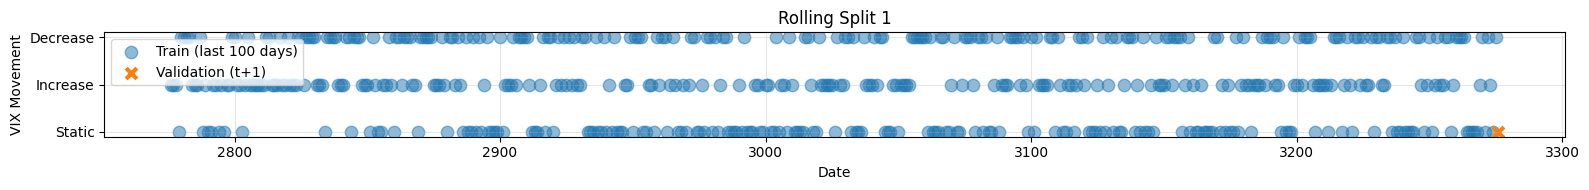

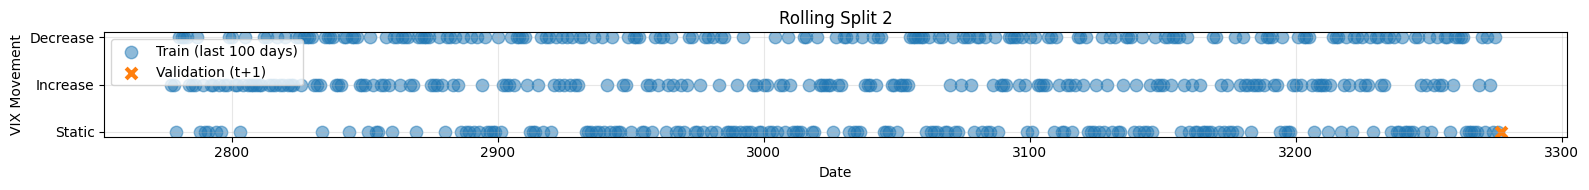

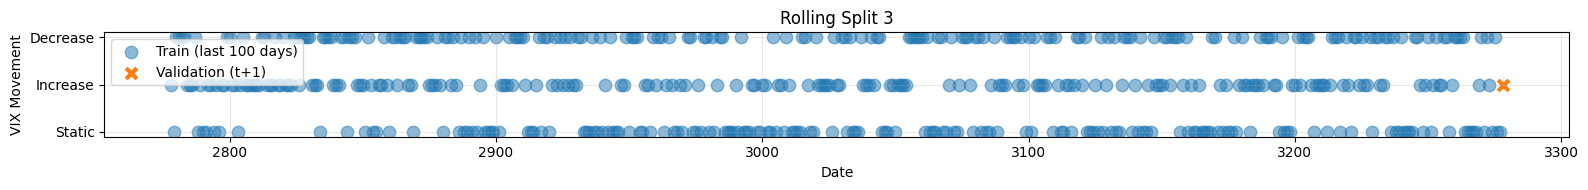

In [ ]:
last_n_days = 500

for i, (X_train, X_val, y_train, y_val) in enumerate(splits[:3]):

    # Last part of training
    y_train_last = y_train.iloc[-last_n_days:]

    # Validation point
    y_val_point = y_val

    # PLOT
    plt.figure(figsize=(16, 2))

    plt.scatter(y_train_last.index, y_train_last,
                label='Train (last 100 days)', s=80, alpha=0.5)

    plt.scatter(y_val_point.index, y_val_point,
                label='Validation (t+1)', s=60, marker='x', linewidths=3)

    plt.xlabel("Date")
    plt.ylabel("VIX Movement")
    plt.yticks([0, 1, 2], ['Static', 'Increase', 'Decrease'])
    plt.title(f"Rolling Split {i+1}")
    plt.legend(loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Model

In [ ]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

scores = []
pred_real = pd.DataFrame()

hmm_cols = ["PC1", "PC2", "PC3"]
scaler = StandardScaler()

# CATBOOST PARAM GRID
param_grid = {
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
    "depth": [4, 6, 7, 8]
}

# LOOP OVER SPLITS
for i, (X_train, X_val, Y_train, Y_val) in enumerate(splits):

    # HMM REGIME DETECTION
    X_train_hmm_scaled = scaler.fit_transform(X_train[hmm_cols])

    hmm = VariationalGaussianHMM(
        n_components=3,
        covariance_type="full",
        n_iter=1400,
        tol=1e-3,
        random_state=42,
        init_params="stmc",
        params="stmc"
    )

    hmm.fit(X_train_hmm_scaled)

    train_probs = hmm.predict_proba(X_train_hmm_scaled)

    X_val_hmm_scaled = scaler.transform(X_val[hmm_cols])
    val_probs = hmm.predict_proba(X_val_hmm_scaled)

    # ADD HMM FEATURES
    X_train_copy = X_train.copy()
    X_val_copy = X_val.copy()

    for s in range(train_probs.shape[1]):
        X_train_copy[f"hmm_state_{s}"] = train_probs[:, s]
        X_val_copy[f"hmm_state_{s}"] = val_probs[:, s]

    # CATBOOST MODEL
    model_cat = CatBoostClassifier(
        iterations=6000,
        l2_leaf_reg=9,
        random_strength=2,
        bagging_temperature=0.5,
        rsm=0.85,
        loss_function='MultiClass',
        eval_metric='TotalF1',
        early_stopping_rounds=150,
        random_seed=42,
        verbose=False
    )

    pipeline = Pipeline([
        ('poly', PolynomialFeatures(include_bias=False)),
        ('scaler', StandardScaler()),
        ('logreg', model)
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid,
        scoring='precision_weighted',
        cv=2
    )

    grid.fit(X_train_copy, Y_train)
    best_model = grid.best_estimator_

    # PREDICTIONS
    preds_stack = best_model.predict(X_val_copy)

    # STORE RESULTS
    pred_real = pd.concat([
        pred_real,
        pd.DataFrame({
            'pred_class': preds_stack,
            'real_class': Y_val.values.ravel(),
            'residual_class': Y_val.values.ravel() - preds_stack,
            'val_regime': hmm.predict(X_val_hmm_scaled)
        }, index=Y_val.index)
    ])

    # METRICS
    precision = precision_score(
        Y_val,
        preds_stack,
        zero_division=0,
        average="weighted"
    )

    scores.append({
        'split': i + 1,
        'degree': grid.best_params_['poly__degree'],
        'depth': grid.best_params_['logreg__depth'],
        'precision_weighted': precision
    })

    print(
        f"Split {i+1}/{len(splits)} completed. "
        f"Best degree: {grid.best_params_['poly__degree']}, "
        f"Best depth: {grid.best_params_['logreg__depth']}"
    )

# FINAL METRICS
metrics_df = pd.DataFrame(scores)
precision_mean = round(metrics_df['precision_weighted'].mean(), 2)

print("Mean precision across models:", precision_mean)

## Best Model

In [ ]:
pred_real = pd.DataFrame()

hmm_cols = ["PC1", "PC2", "PC3"]

model_cat = CatBoostClassifier(
    iterations=6000,
    learning_rate=0.01,
    depth=7,
    l2_leaf_reg=9,
    random_strength=2,
    bagging_temperature=0.5,
    rsm=0.85,
    loss_function='MultiClass',
    eval_metric='TotalF1',
    early_stopping_rounds=150,
    random_seed=42,
    verbose=False
)

for i, (X_train, X_test, Y_train, Y_test) in enumerate(splits):

    # --- SCALER ---
    scaler = StandardScaler()

    X_train_hmm_scaled = scaler.fit_transform(X_train[hmm_cols])
    X_test_hmm_scaled = scaler.transform(X_test[hmm_cols])

    # --- HMM ---
    hmm = VariationalGaussianHMM(
        n_components=3,
        covariance_type="full",
        n_iter=1400,
        tol=1e-3,
        random_state=42,
        init_params="stmc",
        params="stmc"
    )

    hmm.fit(X_train_hmm_scaled)

    train_probs = hmm.predict_proba(X_train_hmm_scaled)
    test_probs = hmm.predict_proba(X_test_hmm_scaled)

    # --- FEATURES ---
    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()

    for s in range(train_probs.shape[1]):
        X_train_copy[f"hmm_state_{s}"] = train_probs[:, s]
        X_test_copy[f"hmm_state_{s}"] = test_probs[:, s]

    # --- MODEL ---
    model_cat.fit(X_train_copy, Y_train.values.ravel())

    preds_stack = model_cat.predict(X_test_copy).ravel()
    probs_stack = model_cat.predict_proba(X_test_copy)

    # --- SAVE ---
    pred_real = pd.concat([
        pred_real,
        pd.DataFrame({
            'pred_class': preds_stack,
            'real_class': Y_test.values.ravel(),
            'residual_class': Y_test.values.ravel() - preds_stack,
            'test_regime': hmm.predict(X_test_hmm_scaled),
            'proba_class_0': probs_stack[:, 0],
            'proba_class_1': probs_stack[:, 1],
            'proba_class_2': probs_stack[:, 2],
        }, index=Y_test.index)
    ])

    precision = precision_score(
        Y_test.values.ravel(),
        preds_stack,
        zero_division=0,
        average="weighted"
    )

    print(f"Split {i+1}/{len(splits)} completed. Precision: {precision:.4f}")

# FINAL SCORE
precision_mean = round(
    precision_score(pred_real['real_class'], pred_real['pred_class'], average='weighted'),
    4
)

print("Mean precision across all splits:", precision_mean)

## Backtesting


In [9]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

def clean_features(X):
    """
    Handle missing values and infinite values.
    """
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.ffill().fillna(0)
    return X.astype(np.float64)


def build_pipeline_pca(n_components=14):
    """
    PCA preprocessing pipeline with scaling and cleaning.
    """
    return Pipeline([
        ("clean", FunctionTransformer(clean_features)),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components))
    ])

def backtesting_prod(test_size,model,data):

  pred_real = pd.DataFrame()

  hmm_cols = ["PC1", "PC2", "PC3"]

  # 1. FINAL HOLDOUT SPLIT
  test_start = len(data) - test_size

  X = clean_features(data.drop(columns=["Intraday_VIX_Move"]))
  y = data["Intraday_VIX_Move"].astype(float)

  X_train_full = X.iloc[:test_start]
  y_train_full = y.iloc[:test_start]

  X_test = X.iloc[test_start:]
  y_test = y.iloc[test_start:]

  # 2. PCA (FIT ON TRAIN ONLY)
  pca_pipeline = build_pipeline_pca(n_components=14)
  pca_pipeline.fit(X_train_full)

  X_train_pca = pd.DataFrame(
      pca_pipeline.transform(X_train_full),
      index=X_train_full.index,
      columns=[f"PC{i+1}" for i in range(14)]
  )

  X_test_pca = pd.DataFrame(
      pca_pipeline.transform(X_test),
      index=X_test.index,
      columns=[f"PC{i+1}" for i in range(14)]
  )

  # 3. HMM (FIT ON TRAIN ONLY)
  scaler_hmm = StandardScaler()

  X_train_hmm_scaled = scaler_hmm.fit_transform(X_train_pca[hmm_cols])
  X_test_hmm_scaled = scaler_hmm.transform(X_test_pca[hmm_cols])

  hmm = VariationalGaussianHMM(
      n_components=3,
      covariance_type="full",
      n_iter=1400,
      tol=1e-3,
      random_state=42
  )

  hmm.fit(X_train_hmm_scaled)

  train_probs = hmm.predict_proba(X_train_hmm_scaled)
  test_probs = hmm.predict_proba(X_test_hmm_scaled)

  # 4. ADD HMM FEATURES
  X_train_final = X_train_pca.copy()
  X_test_final = X_test_pca.copy()

  for s in range(train_probs.shape[1]):
      X_train_final[f"hmm_state_{s}"] = train_probs[:, s]
      X_test_final[f"hmm_state_{s}"] = test_probs[:, s]

  # 5. MODEL (PRODUCTION TRAIN)

  model.fit(X_train_final, y_train_full.values.ravel())

  # 6. PREDICTION (HOLDOUT TEST)
  preds = model.predict(X_test_final).ravel()
  probs = model.predict_proba(X_test_final)

  # 7. RESULTS
  pred_real = pd.DataFrame({
      "pred_class": preds,
      "real_class": y_test.values.ravel(),
      "residual_class": y_test.values.ravel() - preds,
      "test_regime": hmm.predict(X_test_hmm_scaled),
      "proba_class_0": probs[:, 0],
      "proba_class_1": probs[:, 1],
      "proba_class_2": probs[:, 2],
  }, index=y_test.index)

  return pred_real

In [51]:
model_cat = CatBoostClassifier(
    iterations=6000,
    learning_rate=0.01,
    depth=7,
    l2_leaf_reg=9,
    random_strength=2,
    bagging_temperature=0.5,
    rsm=0.85,
    loss_function='MultiClass',
    eval_metric='TotalF1',
    early_stopping_rounds=150,
    random_seed=42,
    verbose=False
)

In [52]:
backtesting_res = backtesting_prod(test_size=200,model=model_cat, data=data)

precision = precision_score(backtesting_res['real_class'],backtesting_res['pred_class'],average="weighted",zero_division=0)
f1 = f1_score(backtesting_res['real_class'],backtesting_res['pred_class'],average="weighted")
print(f"Final Production Backtesting Metrics: {precision:.2f}, {f1:.2f}")

Final Production Backtesting Metrics: 0.49, 0.46


In [53]:
test_sizes = [20, 40, 100, 200]

results = []

for ts in test_sizes:

    backtesting_res = backtesting_prod(
        test_size=ts,
        model=model_cat,
        data=data
    )

    precision = precision_score(
        backtesting_res['real_class'],
        backtesting_res['pred_class'],
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        backtesting_res['real_class'],
        backtesting_res['pred_class'],
        average="weighted"
    )

    results.append({
        "test_size": ts,
        "precision": precision,
        "f1_score": f1
    })

metrics_df = pd.DataFrame(results)

print(metrics_df)

   test_size  precision  f1_score
0         20   0.494737  0.232889
1         40   0.721591  0.442776
2        100   0.517336  0.472616
3        200   0.487445  0.461853


## Evaluate

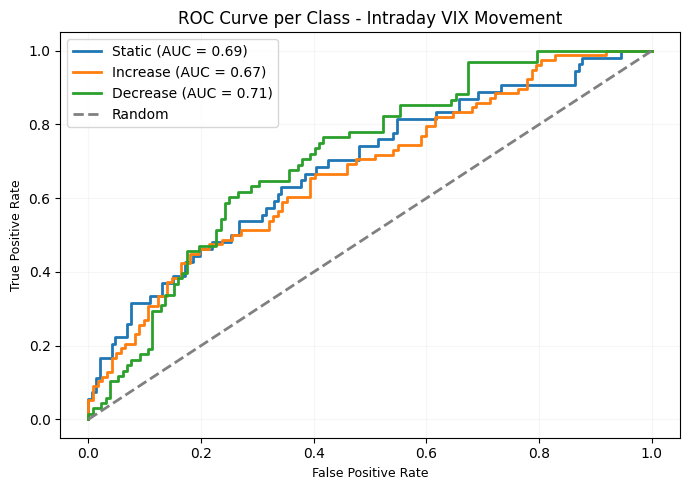

In [54]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# TRUE LABELS
y_true = backtesting_res['real_class'].values
classes = [0, 1, 2]

y_true_bin = label_binarize(y_true, classes=classes)

labels = ['Static', 'Increase', 'Decrease']

# PROBABILITIES MATRIX
y_score = np.column_stack([
    backtesting_res['proba_class_0'].values if 'proba_class_0' in backtesting_res.columns else None,
    backtesting_res['proba_class_1'].values,
    backtesting_res['proba_class_2'].values if 'proba_class_2' in backtesting_res.columns else None
])

# fallback if only 2-class model
if y_score.shape[1] != len(classes):
    raise ValueError("ROC multiclass requires probability per class")

# PLOT ROC
plt.figure(figsize=(7, 5))

roc_aucs = []

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    roc_aucs.append(roc_auc)

    plt.plot(fpr, tpr, lw=2,
             label=f'{labels[i]} (AUC = {roc_auc:.2f})')

# Random baseline
plt.plot([0, 1], [0, 1],
         color='gray', linestyle='--', lw=2,
         label='Random')

# STYLE
plt.xlabel('False Positive Rate', fontsize=9)
plt.ylabel('True Positive Rate', fontsize=9)
plt.title('ROC Curve per Class - Intraday VIX Movement', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(alpha=0.1)
plt.tight_layout()

plt.show()

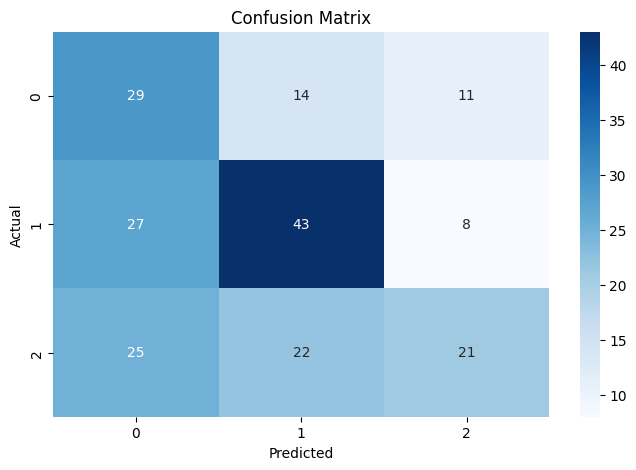

F1 Score:  0.46


In [55]:
cm = confusion_matrix(backtesting_res['real_class'], backtesting_res['pred_class'])
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# F1 Score
f1 = f1_score(backtesting_res['real_class'], backtesting_res['pred_class'], average='macro')
print("F1 Score: ", round(f1, 2))

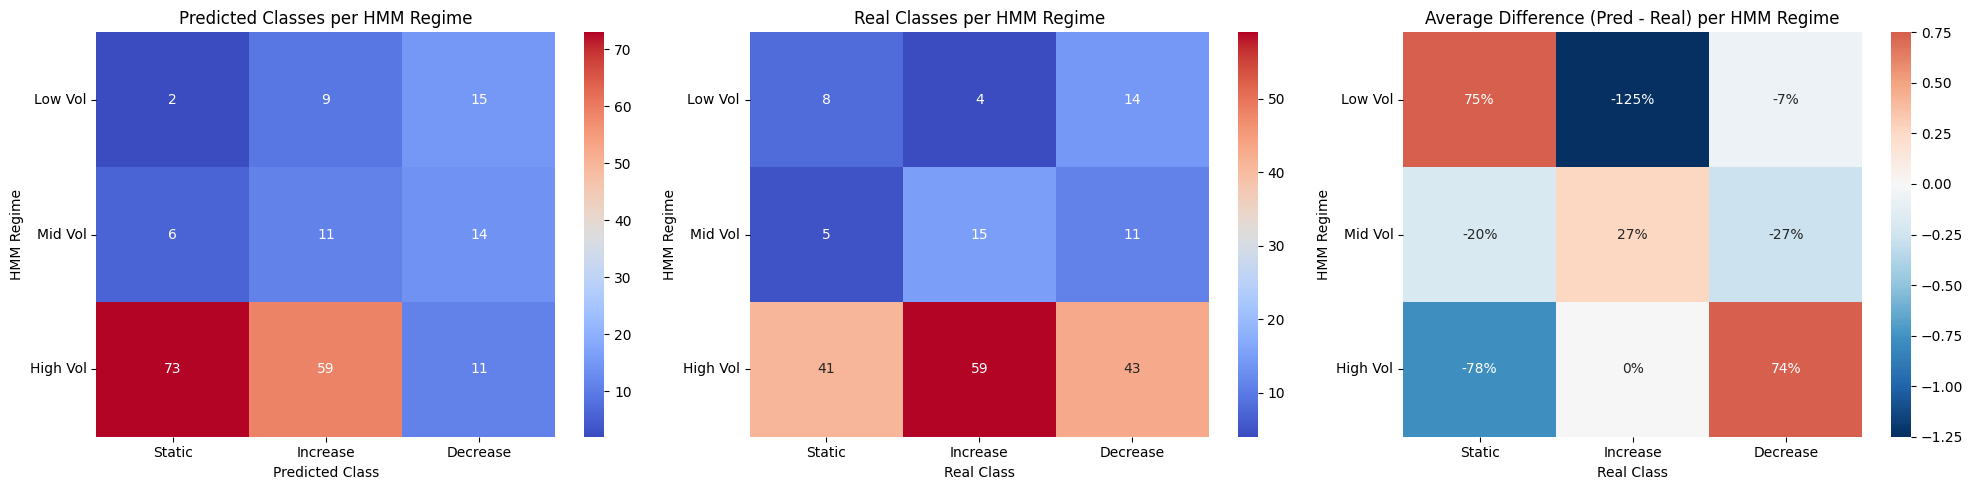

In [56]:
# Compute difference between predicted and real classes
backtesting_res['diff_class'] = backtesting_res['pred_class'] - backtesting_res['real_class']

# Pivot tables
heat_pred = pd.crosstab(backtesting_res['test_regime'], backtesting_res['pred_class'])
heat_real = pd.crosstab(backtesting_res['test_regime'], backtesting_res['real_class'])
heat_diff = (heat_real - heat_pred)/heat_real

# Create figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Heatmap of predictions
sns.heatmap(heat_pred, annot=True, fmt='d', cmap='coolwarm', ax=axes[0])
axes[0].set_xticks([0.5,1.5,2.5])
axes[0].set_xticklabels(["Static", "Increase", "Decrease"], rotation=0)
axes[0].set_yticks([0.5,1.5,2.5])
axes[0].set_yticklabels(['Low Vol','Mid Vol','High Vol'], rotation=0)
axes[0].set_title("Predicted Classes per HMM Regime")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("HMM Regime")

# Heatmap of real classes
sns.heatmap(heat_real, annot=True, fmt='d', cmap='coolwarm', ax=axes[1])
axes[1].set_xticks([0.5,1.5,2.5])
axes[1].set_xticklabels(["Static", "Increase", "Decrease"], rotation=0)
axes[1].set_yticks([0.5,1.5,2.5])
axes[1].set_yticklabels(['Low Vol','Mid Vol','High Vol'], rotation=0)
axes[1].set_title("Real Classes per HMM Regime")
axes[1].set_xlabel("Real Class")
axes[1].set_ylabel("HMM Regime")

# Heatmap of differences (Predicted - Real)
sns.heatmap(heat_diff, annot=True, fmt=".0%", cmap='RdBu_r', center=0, ax=axes[2])
axes[2].set_xticks([0.5,1.5,2.5])
axes[2].set_xticklabels(["Static", "Increase", "Decrease"], rotation=0)
axes[2].set_yticks([0.5,1.5,2.5])
axes[2].set_yticklabels(['Low Vol','Mid Vol','High Vol'], rotation=0)
axes[2].set_title("Average Difference (Pred - Real) per HMM Regime")
axes[2].set_xlabel("Real Class")
axes[2].set_ylabel("HMM Regime")

plt.tight_layout()
plt.show()